In [107]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc
import xgboost as xgb 
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from src.processing import Processing
import config
from sklearn.feature_selection import SelectKBest, chi2
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import warnings
from src.datasplitting import DataSplitting
warnings.filterwarnings('ignore')
from sklearn.model_selection import GridSearchCV, PredefinedSplit, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, precision_recall_curve, auc, classification_report
)
from src.processing import Processing
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from collections import Counter
from src.balance import split_data_nested_cv_ts, split_data, drop_mice_group, balance_classes_by_undersampling, balance_classes_by_undersampling_features_and_target, balance_before_merge, oversample_and_merge, ensemble_sample_and_merge

In [108]:
# Step 1: Load and preprocess the data
dataclass = Processing(source_path=config.RADIOMICS_FINAL_FEATURES, all_features=False)
dataclass.read()
# df = dataclass.preprocess()  # Assume this keeps mouse IDs for splitting
df = dataclass.df
DS_LENGTH = len(df)

In [109]:
N_SPLITS = 5
TEST_SIZE = 0.3 
SEED = 42
SAMPLE_SIZE = 10
TOP_FEATURES = 15

# Hyperparameter grid for XGBClassifier
PARAM_GRID = {
    'xgbclassifier__n_estimators': [100, 500, 1000],
    'xgbclassifier__learning_rate': [0.01, 0.05, 0.1],
    'xgbclassifier__max_depth': [3, 4, 5, 7],
    'xgbclassifier__subsample': [0.6, 0.7, 0.8, 1.0],
    'xgbclassifier__min_child_weight': [1, 5, 10],
    'xgbclassifier__gamma': [0.5, 1, 1.5, 2, 5],
    'xgbclassifier__colsample_bytree': [0.6, 0.8, 1.0]
}
xgb_params = {
    'xgbclassifier__colsample_bytree': 0.6,
    'xgbclassifier__gamma': 0.5,
    'xgbclassifier__learning_rate': 0.01,
    'xgbclassifier__max_depth': 3,
    'xgbclassifier__min_child_weight': 1,
    'xgbclassifier__n_estimators': 100,
    'xgbclassifier__subsample': 0.6
}
OUTPUT_DIR = 'output'


In [110]:
def train_test_and_show_results(split_method: str, m_data: dict, plot_feature_importances_per_fold: bool = True, plot_roc_and_feature_importances: bool = True, show_fold_results: bool = True,
                                tune_hyperparameters: bool = False, param_grid: dict = None, xgb_params: dict = None, show_label: bool = True):

    # Track results for each fold
    fold_accuracies, fold_f1_macros, fold_precisions, fold_recalls, fold_roc_aucs, fold_f1_micros, fold_f1_weighted, feature_importances, true_positives, false_positives, true_negatives, false_negatives  = [], [], [], [], [], [], [], [], [], [], [], []

    best_params_per_fold = []  # Track best parameters per fold

    # Store ROC curve points for all folds
    roc_curves = []

    split_0_data = next(iter(m_data.values()))

    # feature_names = split_0_data['X_train'].drop(columns=['m_id', ]).columns  # This will be a pandas.Index
    # feature_names = feature_names.str.replace('original_', '', regex=False)

    for fold, split_data in m_data.items():
        print(f"\nFold {fold}:")
        print(f"Original train class distribution: {Counter(split_data['y_train'])}")
        print(f"Original test class distribution: {Counter(split_data['y_test'])}") 
        
        # Check if directory exists
        if not os.path.exists(f"{OUTPUT_DIR}/{split_method}/fold_{fold}"):
            os.makedirs(f"{OUTPUT_DIR}/{split_method}/fold_{fold}")

        # Keep `m_id` for analysis later
        m_id_test = split_data['X_test']['m_id']  # Save `m_id` for test
        day_of_study_test = split_data['X_test']['day_of_study']  # Save `day_of_study` for test

        # Exclude `m_id` and `day_of_study` for training
        X_train = split_data['X_train'].drop(columns=['m_id', 'day_of_study'])
        X_test = split_data['X_test'].drop(columns=['m_id', 'day_of_study'])

        # Get feature names
        feature_names = X_train.columns.str.replace('original_', '', regex=False)

        if tune_hyperparameters:

            # Define the model with hyperparameter tuning
            model = Pipeline([
                ('scaler', StandardScaler()), 
                ('smote', SMOTE(k_neighbors=5, random_state=SEED)),
                ('xgbclassifier', xgb.XGBClassifier(random_state=SEED))
            ])

            grid_search = GridSearchCV(model, param_grid=param_grid, cv=TimeSeriesSplit(n_splits=5), scoring='f1_macro', n_jobs=-1)
            grid_search.fit(X_train, split_data['y_train'])
            best_model = grid_search.best_estimator_
            best_params = grid_search.best_params_
            best_params_per_fold.append(best_params)  # Save best parameters
            print(f"Best parameters for fold {fold}: {best_params}")
        else:
            # Use provided xgb_params or default parameters if not tuning
            model = Pipeline([
                ('scaler', StandardScaler()), 
                ('smote', SMOTE(k_neighbors=5, random_state=SEED)),
                ('xgbclassifier', xgb.XGBClassifier(**(xgb_params or {}), random_state=SEED)),
            ])
            
            model.fit(X_train, split_data['y_train'])
            best_model = model        

        # Extract feature importances from XGBoost
        xgb_model = best_model.named_steps['xgbclassifier']
        importances = xgb_model.feature_importances_

        # Evaluate on the test set
        preds = best_model.predict(X_test)
        preds_proba = best_model.predict_proba(X_test)[:, 1]  # Probability for the positive class
        
        # Calculate metrics
        accuracy = accuracy_score(split_data['y_test'], preds)
        f1_macro = f1_score(split_data['y_test'], preds, average='macro')
        f1_micro = f1_score(split_data['y_test'], preds, average='micro')
        f1_weighted = f1_score(split_data['y_test'], preds, average='weighted')
        precision = precision_score(split_data['y_test'], preds)
        recall = recall_score(split_data['y_test'], preds)

        fpr, tpr, _ = roc_curve(split_data['y_test'], preds_proba, pos_label=1)
        roc_auc = auc(fpr, tpr)

        # If auc is NaN, set to 0
        if np.isnan(roc_auc):
            roc_auc = 0
        
        roc_curves.append((fpr, tpr))

        # Calculate the confusion matrix
        cm = confusion_matrix(split_data['y_test'], preds)

        # Handle cases where the confusion matrix shape is unexpected
        if cm.shape == (1, 1):  # Only one class present
            tn, fp, fn, tp = (cm[0, 0], 0, 0, 0) if split_data['y_test'].iloc[0] == 0 else (0, 0, 0, cm[0, 0])
        elif cm.shape == (1, 2):  # One class is missing in y_test
            tn, fp, fn, tp = (cm[0, 0], cm[0, 1], 0, 0)
        elif cm.shape == (2, 1):  # One class is missing in preds
            tn, fp, fn, tp = (0, 0, cm[1, 0], cm[0, 0])
        else:  # Normal case with both classes present
            tn  , fp, fn, tp = cm.ravel()

         # Identify misclassified instances
        misclassified_mask = split_data['y_test'] != preds
        misclassified = pd.DataFrame({
            'm_id': m_id_test[misclassified_mask],
            'day_of_study': day_of_study_test[misclassified_mask],
            'true_label': split_data['y_test'][misclassified_mask],
            'predicted_label': preds[misclassified_mask]
        })
        # Save misclassified instances for this fold
        misclassified.to_csv(f"{OUTPUT_DIR}/{split_method}/fold_{fold}/misclassified.csv", index=False)

        if show_fold_results:
            # Print fold results
            print(f"\n\nFold {fold} results:")
            print(f"Accuracy: {accuracy:.4f}")
            print(f"F1-macro: {f1_macro:.4f}")
            print(f"F1-micro: {f1_micro:.4f}")
            print(f"F1-weighted: {f1_weighted:.4f}")
            print(f"Precision: {precision:.4f}")
            print(f"Recall: {recall:.4f}")
            print(f"ROC AUC: {roc_auc:.4f}")
            print(f"True Positives: {tp}, False Negatives: {fn}, False Positives: {fp}, True Negatives: {tn}")
            print(f"Classification report:\n{classification_report(split_data['y_test'], preds)}")

            print(f"Days of study for training set: {split_data['X_train']['day_of_study'].unique()}")
            print(f"Days of study for test set: {split_data['X_test']['day_of_study'].unique()}")
            print(f"Percentage of data used for training: {len(split_data['X_train']) / DS_LENGTH * 100:.2f}%")

            print(f"Misclassified instances in fold {fold}:")
            print(misclassified[['m_id', 'day_of_study', 'true_label', 'predicted_label']].head())

            print("-" * 50)
        
        if plot_feature_importances_per_fold:
            # Plot top k features for this fold
            top_indices = np.argsort(importances)[-TOP_FEATURES:][::-1]
            top_importances = importances[top_indices]

            plt.figure(figsize=(12, 4))
            plt.subplot(1, 2, 1)
            plt.barh(range(TOP_FEATURES), top_importances, color='skyblue', align='center')
            plt.yticks(range(TOP_FEATURES), feature_names[top_indices], ha="right")
            plt.ylabel("Feature Index")
            plt.xlabel("Importance")
            plt.title(f"Top {TOP_FEATURES} Feature Importances (Fold {fold})")
            # Plot confusion matrix
            plt.subplot(1, 2, 2)
            cm = confusion_matrix(split_data['y_test'], preds)
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
            plt.title(f'Confusion Matrix (Fold {fold})')
            plt.xlabel('Predicted Label')
            plt.ylabel('True Label')
            plt.tight_layout()
            plt.show()

        # Track results
        fold_accuracies.append(accuracy)
        fold_f1_macros.append(f1_macro)
        fold_f1_micros.append(f1_micro)
        fold_f1_weighted.append(f1_weighted)
        fold_precisions.append(precision)
        fold_recalls.append(recall)
        fold_roc_aucs.append(roc_auc)
        feature_importances.append(importances)
        true_positives.append(tp)
        false_negatives.append(fn)
        false_positives.append(fp)
        true_negatives.append(tn)

        # Save fold metrics to a CSV file
        fold_metrics = pd.DataFrame({
            'accuracy': [accuracy],
            'f1_macro': [f1_macro],
            'f1_micro': [f1_micro],
            'f1_weighted': [f1_weighted],
            'precision': [precision],
            'recall': [recall],
            'roc_auc': [roc_auc],
            'true_positives': [tp],
            'false_negatives': [fn],
            'false_positives': [fp],
            'true_negatives': [tn],
            'days_of_study_in_train': [split_data['X_train']['day_of_study'].unique()],
            'days_of_study_in_test': [split_data['X_test']['day_of_study'].unique()],
            'percentage_of_data_in_train': [len(split_data['X_train']) / DS_LENGTH * 100]
        })

        fold_metrics.to_csv(f"{OUTPUT_DIR}/{split_method}/fold_{fold}/metrics.csv", index=False)

        # Save top 15 feature importances to a csv file
        # top_indices = np.argsort(importances)[-TOP_FEATURES:][::-1]
        top_indices = np.argsort(importances)[::-1]
        top_importances = importances[top_indices]
        top_features = pd.DataFrame({
            'feature': feature_names[top_indices],
            'importance': top_importances
        })

        top_features.to_csv(f"{OUTPUT_DIR}/{split_method}/fold_{fold}/top_features.csv", index=False)

    print(f"\nAll Folds Completed.") 
    print("\n--------------------------------------------------")
    print("\nSummary of Results:\n")

    # Display best parameters summary
    if tune_hyperparameters:
        print("\nBest parameters per fold:")
        for fold, params in enumerate(best_params_per_fold):
            print(f"Fold {fold}: {params}")

    # Calculate mean importances across folds
    mean_importances = np.mean(feature_importances, axis=0)
    # Get indices of the top k features by mean
    top_indices_mean = np.argsort(mean_importances)[-TOP_FEATURES:][::-1]
    top_importances_mean = mean_importances[top_indices_mean]
    
    if plot_roc_and_feature_importances:

        # Plotting ROC curve side by side
        plt.figure(figsize=(15, 5))

        # ROC Curve Plot
        plt.subplot(1, 2, 1)  # First plot (1 row, 2 columns, 1st plot)
        if show_label:
            for i, (fpr, tpr) in enumerate(roc_curves):
                plt.plot(fpr, tpr, label=f'Fold {i} (ROC AUC = {fold_roc_aucs[i]:.2f})')
        else:
            for i, (fpr, tpr) in enumerate(roc_curves):
                plt.plot(fpr, tpr)
        plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
        plt.title("ROC Curve Across Folds")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend(loc="lower right")

        plt.subplot(1, 2, 2)  # Second plot (1 row, 2 columns, 2nd plot)
        plt.barh(range(TOP_FEATURES), top_importances_mean, color='skyblue', align='center')
        plt.yticks(range(TOP_FEATURES), feature_names[top_indices_mean])
        plt.ylabel("Feature Index")
        plt.xlabel("Importance")
        plt.title(f"Top {TOP_FEATURES} Feature Importances (Mean)")

        # Display the plots side by side
        plt.tight_layout()  # Adjust layout for better spacing
        plt.show()

    # Display summary statistics across folds
    print(f"\nSummary Across Folds:")
    print(f"Mean accuracy: {np.mean(fold_accuracies):.4f}")
    print(f"Mean F1-macro: {np.mean(fold_f1_macros):.4f}")
    print(f"Mean F1-micro: {np.mean(fold_f1_micros):.4f}")
    print(f"Mean F1-weighted: {np.mean(fold_f1_weighted):.4f}")
    print(f"Mean precision: {np.mean(fold_precisions):.4f}")
    print(f"Mean recall: {np.mean(fold_recalls):.4f}")
    print(f"Mean ROC AUC: {np.mean(fold_roc_aucs):.4f}")

    # Standard deviation, variance, coefficient of variation and dispersion index of f1_macro
    print(f"\nStandard Deviation of F1-macro: {np.std(fold_f1_macros):.4f}")
    print(f"Variance of F1-macro: {np.var(fold_f1_macros):.4f}")
    print(f"Coefficient of Variation of F1-macro: {np.std(fold_f1_macros) / np.mean(fold_f1_macros):.4f}")
    print(f"Dispersion Index of F1-macro: {np.var(fold_f1_macros) / np.mean(fold_f1_macros):.4f}")

    print("\n--------------------------------------------------")

    # Save summary statistics to a CSV file
    summary_metrics = pd.DataFrame({
        'accuracy': [np.mean(fold_accuracies)],
        'f1_macro': [np.mean(fold_f1_macros)],
        'f1_micro': [np.mean(fold_f1_micros)],
        'f1_weighted': [np.mean(fold_f1_weighted)],
        'precision': [np.mean(fold_precisions)],
        'recall': [np.mean(fold_recalls)],
        'roc_auc': [np.mean(fold_roc_aucs)],
        'std_f1_macro': [np.std(fold_f1_macros)],
        'var_f1_macro': [np.var(fold_f1_macros)],
        'cv_f1_macro': [np.std(fold_f1_macros) / np.mean(fold_f1_macros)],
        'di_f1_macro': [np.var(fold_f1_macros) / np.mean(fold_f1_macros)]
    })

    summary_metrics.to_csv(f"{OUTPUT_DIR}/{split_method}/summary_metrics.csv", index=False)

    # Save top feature importances and split method in a csv file
    top_features = pd.DataFrame({
        'feature': feature_names[top_indices_mean],
        'importance': top_importances_mean
    })

    top_features.to_csv(f"{OUTPUT_DIR}/{split_method}/top_features.csv", index=False) 

    # Optional: Calculate the most common parameters across folds
    if tune_hyperparameters:
        most_comon_params = max(set(best_params_per_fold), key=best_params_per_fold.count)
        print("\nMost common parameters across folds:")
        print(most_comon_params)

In [111]:
# split_method, m_data = DataSplitting.expanding_window_split_test(df, 5)

# #train_test_and_show_results(m_data, tune_hyperparameters=True, param_grid=PARAM_GRID)
# train_test_and_show_results(split_method=split_method, m_data=m_data, tune_hyperparameters=False, xgb_params= {'xgbclassifier__colsample_bytree': 0.6, 'xgbclassifier__gamma': 0.5,
#  'xgbclassifier__learning_rate': 0.01,
#  'xgbclassifier__max_depth': 3,
#  'xgbclassifier__min_child_weight': 1,
#  'xgbclassifier__n_estimators': 100,
#  'xgbclassifier__subsample': 0.6
# })


Fold 0:
Original train class distribution: Counter({0: 64, 1: 14})
Original test class distribution: Counter({0: 61, 1: 15})


Fold 0 results:
Accuracy: 0.8158
F1-macro: 0.5589
F1-micro: 0.8158
F1-weighted: 0.7626
Precision: 0.6667
Recall: 0.1333
ROC AUC: 0.7475
True Positives: 2, False Negatives: 13, False Positives: 1, True Negatives: 60
Classification report:
              precision    recall  f1-score   support

           0       0.82      0.98      0.90        61
           1       0.67      0.13      0.22        15

    accuracy                           0.82        76
   macro avg       0.74      0.56      0.56        76
weighted avg       0.79      0.82      0.76        76

Days of study for training set: [ 7  8  9 10 11 12 13 14 15 16 17]
Days of study for test set: [17 18 19 20 21]
Percentage of data used for training: 20.42%
Misclassified instances in fold 0:
    m_id  day_of_study  true_label  predicted_label
0   1281            17           1                0
1   1285   

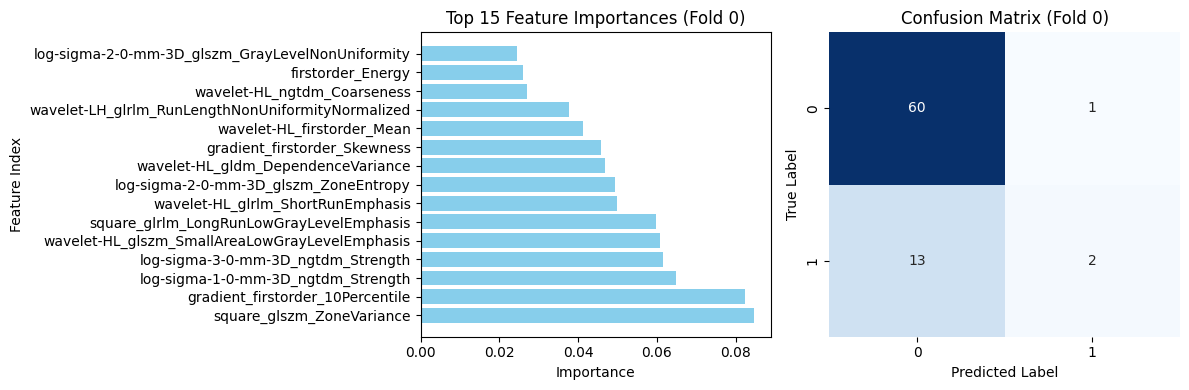


Fold 1:
Original train class distribution: Counter({0: 125, 1: 29})
Original test class distribution: Counter({0: 58, 1: 18})


Fold 1 results:
Accuracy: 0.8289
F1-macro: 0.7587
F1-micro: 0.8289
F1-weighted: 0.8272
Precision: 0.6471
Recall: 0.6111
ROC AUC: 0.8170
True Positives: 11, False Negatives: 7, False Positives: 6, True Negatives: 52
Classification report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89        58
           1       0.65      0.61      0.63        18

    accuracy                           0.83        76
   macro avg       0.76      0.75      0.76        76
weighted avg       0.83      0.83      0.83        76

Days of study for training set: [ 7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
Days of study for test set: [21 22 23 24 25 26]
Percentage of data used for training: 40.31%
Misclassified instances in fold 1:
    m_id  day_of_study  true_label  predicted_label
5   1285            21           1             

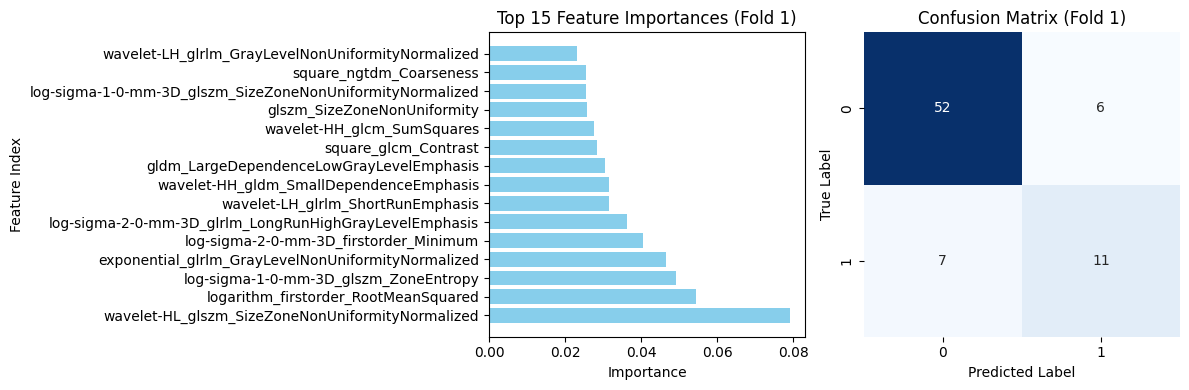


Fold 2:
Original train class distribution: Counter({0: 183, 1: 47})
Original test class distribution: Counter({0: 61, 1: 15})


Fold 2 results:
Accuracy: 0.6579
F1-macro: 0.4854
F1-micro: 0.6579
F1-weighted: 0.6657
Precision: 0.1765
Recall: 0.2000
ROC AUC: 0.6055
True Positives: 3, False Negatives: 12, False Positives: 14, True Negatives: 47
Classification report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.78        61
           1       0.18      0.20      0.19        15

    accuracy                           0.66        76
   macro avg       0.49      0.49      0.49        76
weighted avg       0.67      0.66      0.67        76

Days of study for training set: [ 7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26]
Days of study for test set: [26 27 29 31 33 35]
Percentage of data used for training: 60.21%
Misclassified instances in fold 2:
    m_id  day_of_study  true_label  predicted_label
2   1285            27         

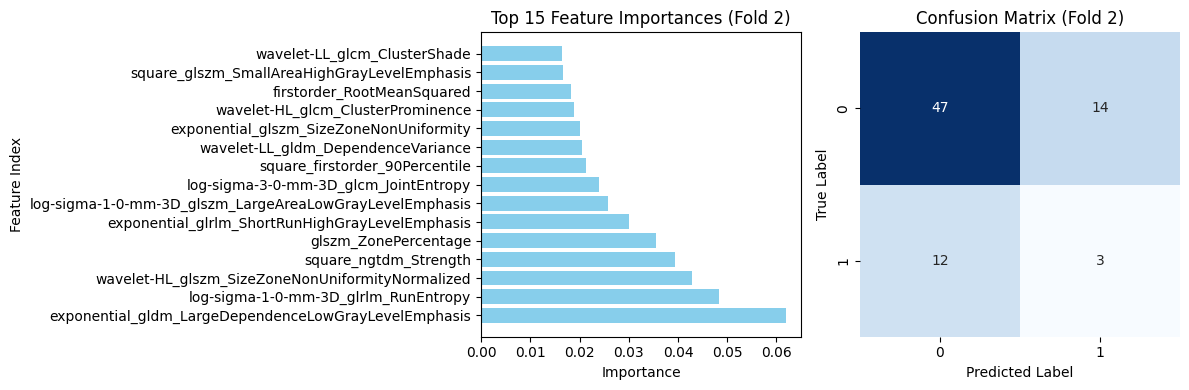


Fold 3:
Original train class distribution: Counter({0: 244, 1: 62})
Original test class distribution: Counter({0: 72, 1: 4})


Fold 3 results:
Accuracy: 0.9211
F1-macro: 0.6789
F1-micro: 0.9211
F1-weighted: 0.9284
Precision: 0.3333
Recall: 0.5000
ROC AUC: 0.9444
True Positives: 2, False Negatives: 2, False Positives: 4, True Negatives: 68
Classification report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.96        72
           1       0.33      0.50      0.40         4

    accuracy                           0.92        76
   macro avg       0.65      0.72      0.68        76
weighted avg       0.94      0.92      0.93        76

Days of study for training set: [ 7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 29 31 33
 35]
Days of study for test set: [35 37 39 41 43 45 47 49]
Percentage of data used for training: 80.10%
Misclassified instances in fold 3:
    m_id  day_of_study  true_label  predicted_label
8   1263    

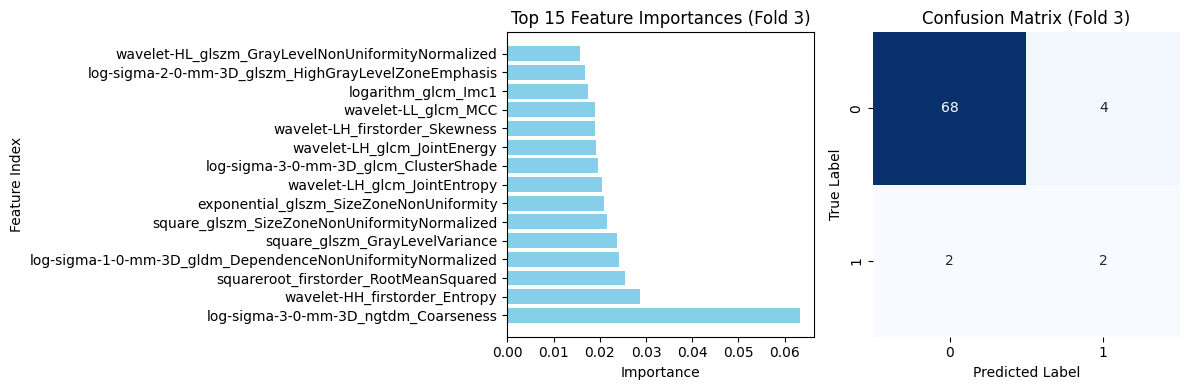


All Folds Completed.

--------------------------------------------------

Summary of Results:



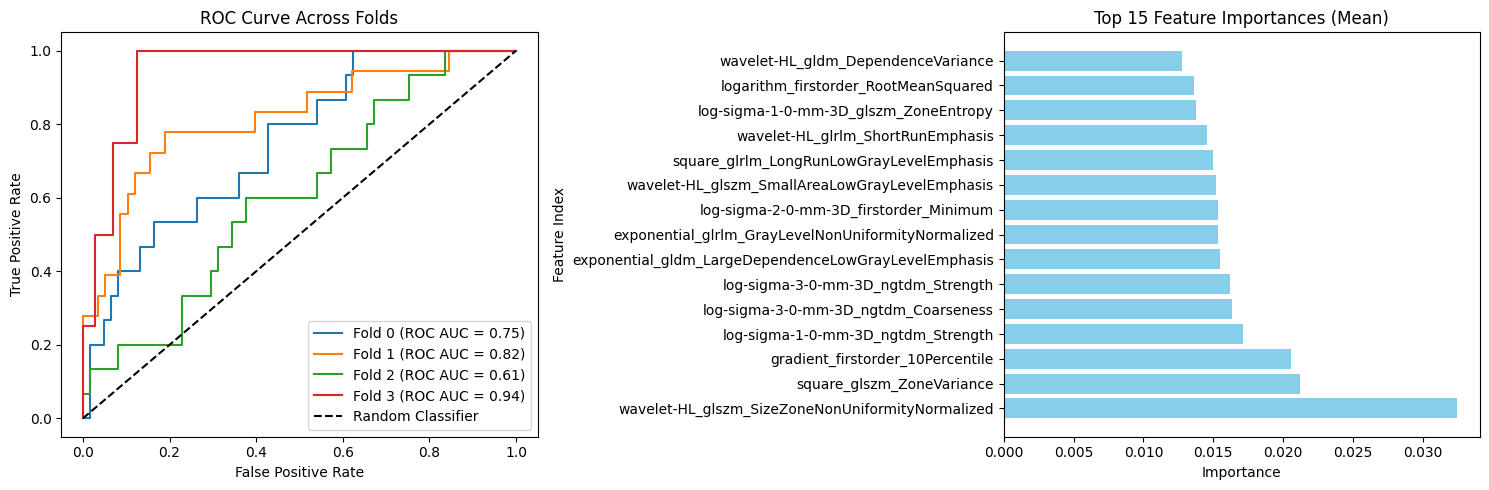


Summary Across Folds:
Mean accuracy: 0.8059
Mean F1-macro: 0.6205
Mean F1-micro: 0.8059
Mean F1-weighted: 0.7960
Mean precision: 0.4559
Mean recall: 0.3611
Mean ROC AUC: 0.7786

Standard Deviation of F1-macro: 0.1055
Variance of F1-macro: 0.0111
Coefficient of Variation of F1-macro: 0.1701
Dispersion Index of F1-macro: 0.0180

--------------------------------------------------


In [112]:
split_method, m_data = DataSplitting.expanding_window_split(df, 4)

#train_test_and_show_results(m_data, tune_hyperparameters=True, param_grid=PARAM_GRID)
train_test_and_show_results(split_method=split_method, m_data=m_data, tune_hyperparameters=False, xgb_params= {'xgbclassifier__colsample_bytree': 0.6, 'xgbclassifier__gamma': 0.5,
 'xgbclassifier__learning_rate': 0.01,
 'xgbclassifier__max_depth': 3,
 'xgbclassifier__min_child_weight': 1,
 'xgbclassifier__n_estimators': 100,
 'xgbclassifier__subsample': 0.6
})

In [113]:
# Ensure output directory exists
if not os.path.exists(f"{OUTPUT_DIR}/{split_method}/top_features"):
    os.makedirs(f"{OUTPUT_DIR}/{split_method}/top_features")

# List to store all fold data
all_folds_data = []

# Read and combine feature importances from all folds
for fold in range(len(m_data.keys())):
    # Load the feature importance file for the current fold
    fold_file = f"{OUTPUT_DIR}/{split_method}/fold_{fold}/top_features.csv"
    if os.path.exists(fold_file):
        fold_data = pd.read_csv(fold_file)
        fold_data['fold'] = fold  # Add fold number for tracking
        all_folds_data.append(fold_data)
    else:
        print(f"File not found for fold {fold}: {fold_file}")

# Combine all fold data into one DataFrame
combined_data = pd.concat(all_folds_data, ignore_index=True)

# Pivot data to include importance per fold as separate columns
importance_per_fold = combined_data.pivot_table(
    index='feature',
    columns='fold',
    values='importance',
    aggfunc='first'
).reset_index()

# Rename fold columns for clarity
importance_per_fold.columns = ['feature'] + [f'Fold_{col}_importance' for col in importance_per_fold.columns if isinstance(col, int)]

# Calculate aggregate metrics for each feature
metrics = combined_data.groupby('feature')['importance'].agg(
    mean_importance='mean',
    std_importance='std'
).reset_index()

# Add variance and coefficient of variation (CV)
metrics['variance'] = metrics['std_importance'] ** 2
metrics['cv'] = metrics['std_importance'] / metrics['mean_importance']

# Merge the fold-level importances with the aggregate metrics
final_table = importance_per_fold.merge(metrics, on='feature', how='left')

# Save the final table to a CSV file
output_file = f"{OUTPUT_DIR}/{split_method}/top_features/aggregated_features_with_folds.csv"
final_table.to_csv(output_file, index=False)

print(f"Aggregated feature importances (including per fold) saved to {output_file}")



Aggregated feature importances (including per fold) saved to output/expanding_window_split/top_features/aggregated_features_with_folds.csv


In [124]:

# Configuración inicial
TOP_N = 15  # Número de features para la lista corta
CV_THRESHOLD = 1  # Umbral para el Coefficient of Variation

# Leer la tabla de features agregadas
aggregated_file = f"{OUTPUT_DIR}/{split_method}/top_features/aggregated_features_with_folds.csv"
features_table = pd.read_csv(aggregated_file)

# Ordenar por Mean Importance
features_table = features_table.sort_values(by="mean_importance", ascending=False)

# Filtrar features consistentes (baja variabilidad)
consistent_features = features_table[features_table['cv'] <= CV_THRESHOLD]

# Generar la lista corta (Top N)
top_features = consistent_features.head(TOP_N)

# Guardar resultados
output_short = f"{OUTPUT_DIR}/{split_method}/top_features/top_{TOP_N}_features.csv"
output_full = f"{OUTPUT_DIR}/{split_method}/top_features/consistent_features.csv"

top_features.to_csv(output_short, index=False)
consistent_features.to_csv(output_full, index=False)

print(f"Top {TOP_N} features saved to: {output_short}")
print(f"Consistent features saved to: {output_full}")

Top 15 features saved to: output/expanding_window_split/top_features/top_15_features.csv
Consistent features saved to: output/expanding_window_split/top_features/consistent_features.csv


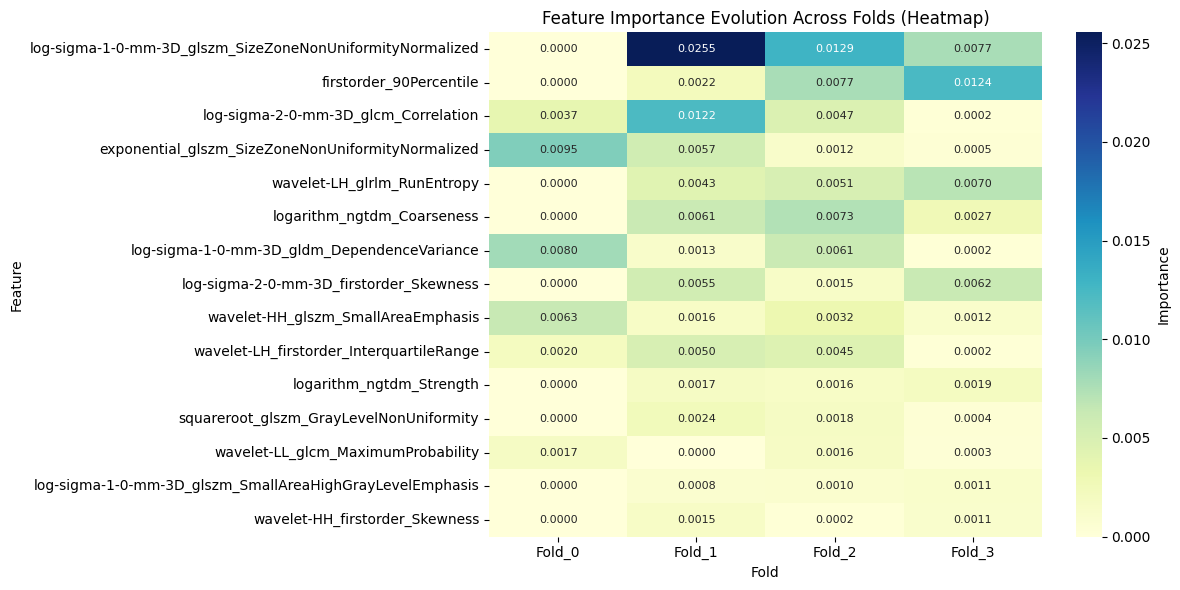

In [135]:
# Read the top features
top_features = pd.read_csv(f"{OUTPUT_DIR}/{split_method}/top_features/top_{TOP_N}_features.csv")

# Prepare data for heatmap: Extract importance values for the top features
heatmap_data = []

for feature in top_features['feature']:
    importance_values = features_table[features_table['feature'] == feature].iloc[:, 1:5].values.flatten()
    heatmap_data.append(importance_values)

# Convert to DataFrame for better handling
heatmap_df = pd.DataFrame(heatmap_data, columns=[f"Fold_{i}" for i in range(len(importance_values))], index=top_features['feature'])

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_df, annot=True, cmap="YlGnBu", cbar_kws={'label': 'Importance'}, fmt='.4f', annot_kws={"size": 8})
plt.title("Feature Importance Evolution Across Folds (Heatmap)")
plt.xlabel("Fold")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

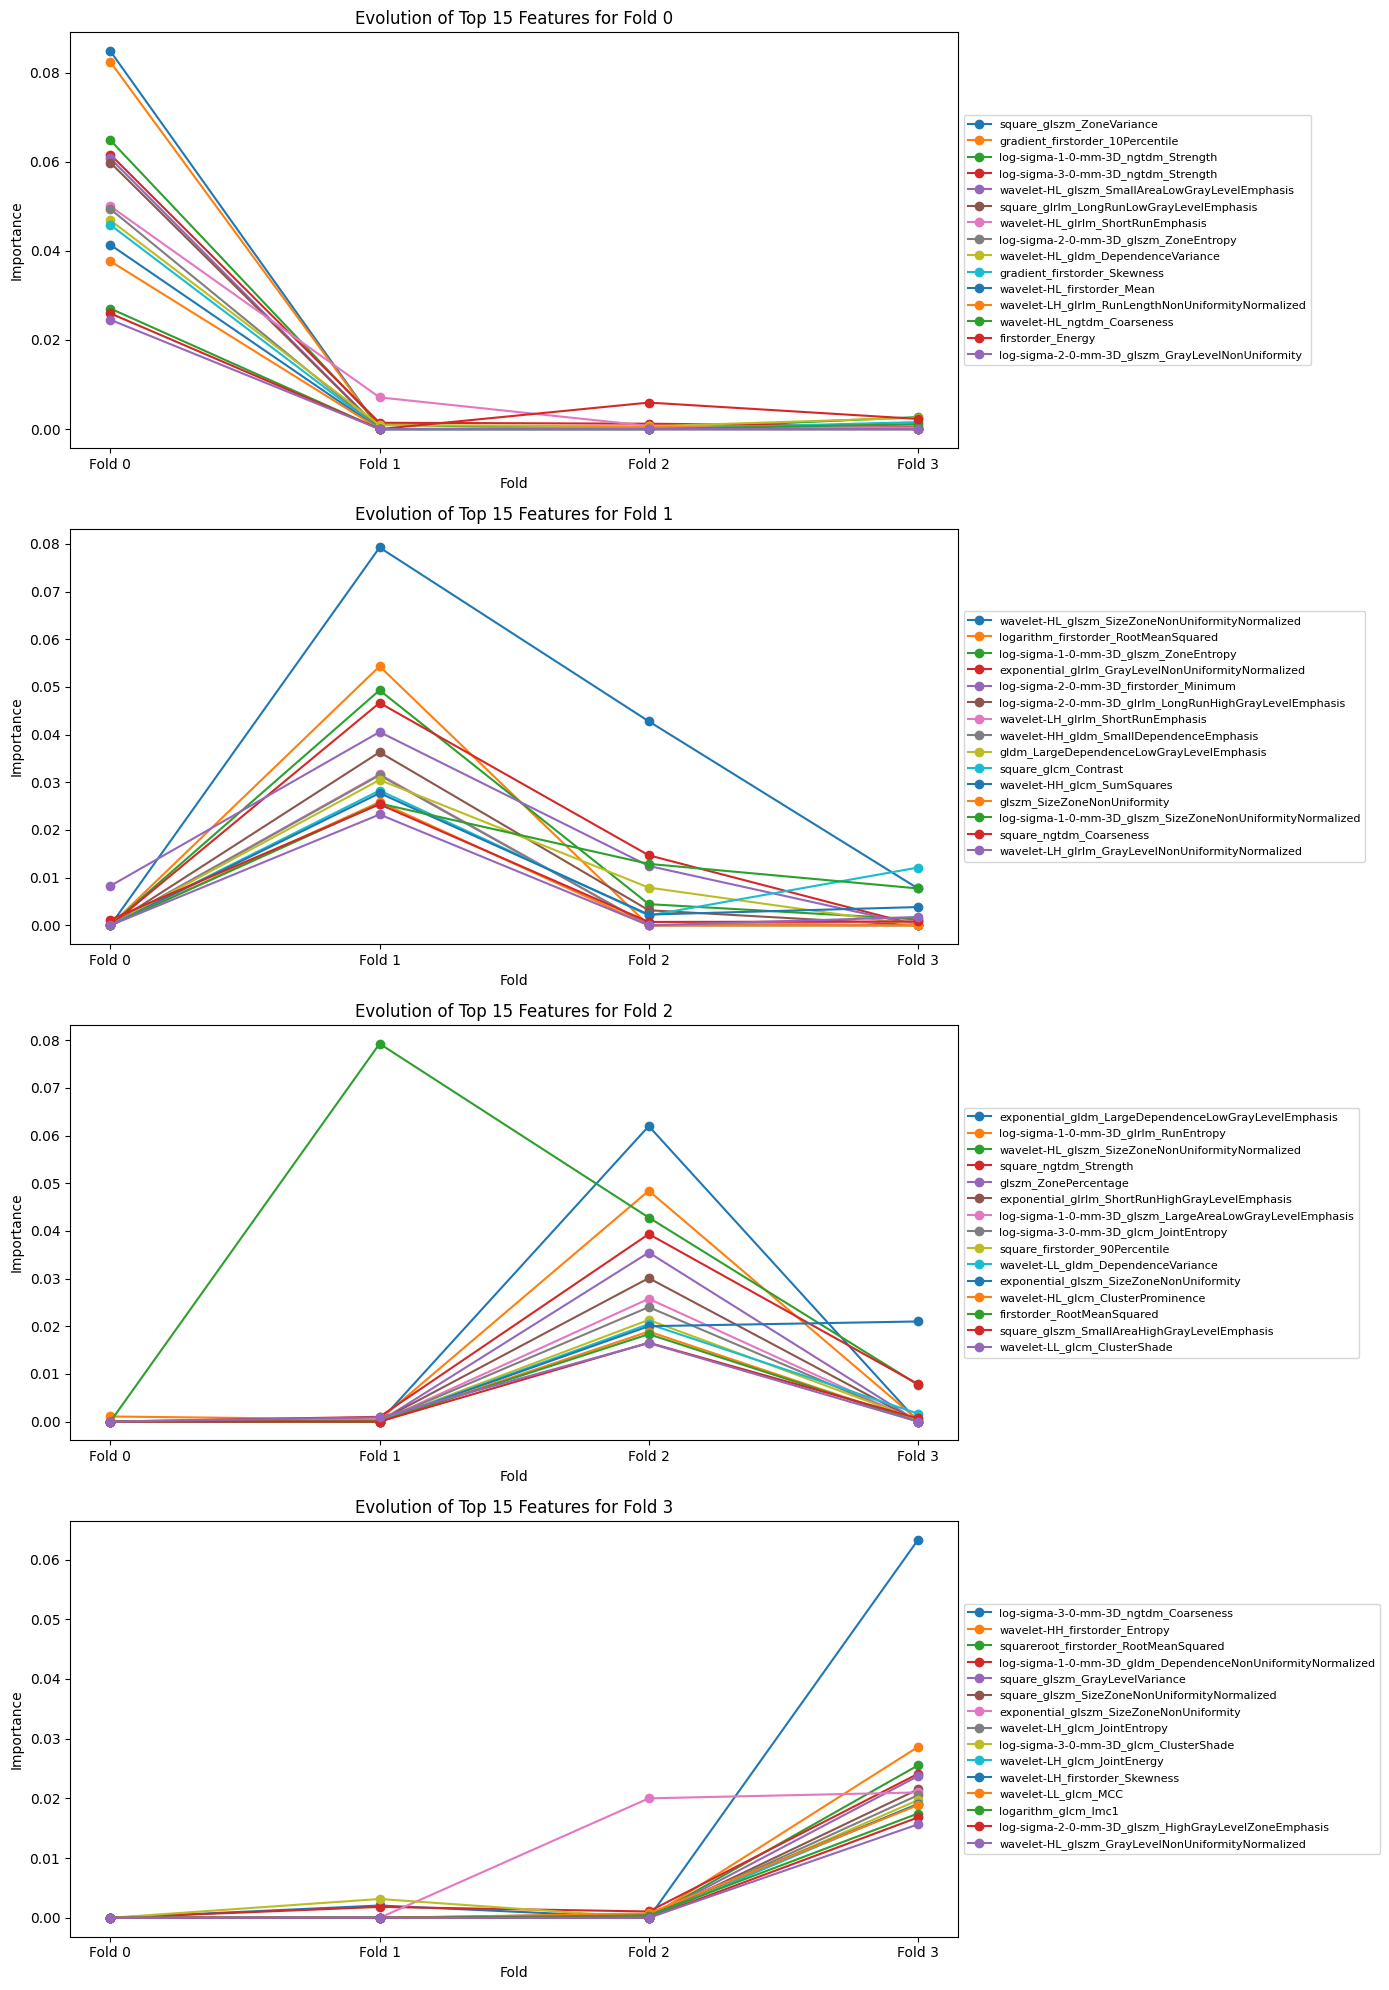

In [133]:
# Prepare data storage
feature_importance_data = []

# Iterate over the folds to load top feature data
for fold in range(4):  # Assuming there are 4 folds
    fold_file = os.path.join(OUTPUT_DIR, split_method, f"fold_{fold}", "top_features.csv")
    
    # Check if the file exists
    if os.path.exists(fold_file):
        fold_features = pd.read_csv(fold_file)
        
        # Extract the top 15 features by importance
        top_features_fold = fold_features.nlargest(15, 'importance')  # Top 15 features by importance
        feature_importance_data.append(top_features_fold)

# Load the aggregated features data to track importance over folds
aggregated_features_file = os.path.join(OUTPUT_DIR, split_method, 'top_features', 'aggregated_features_with_folds.csv')
aggregated_features = pd.read_csv(aggregated_features_file)

# Prepare the plotting data: we'll track importance evolution across the 4 folds
# We'll use the top features from fold 0 as a reference
top_features = feature_importance_data[0]['feature']  # Assuming same top features for all folds

# Prepare subplots for each fold, now with 4 rows and 1 column
fig, axs = plt.subplots(4, 1, figsize=(14, 20))  # 4 subplots (4x1)

# Iterate over each fold and plot the feature importance evolution
for i, fold_data in enumerate(feature_importance_data):
    # Get the top 15 features for this fold
    top_features_fold = fold_data.nlargest(15, 'importance')['feature']
    
    # Initialize a list to store the importance values for this fold
    fold_importance = []

    # Get the corresponding importance values from aggregated features file
    for feature in top_features_fold:
        importance_values = aggregated_features[aggregated_features['feature'] == feature][
            [f'Fold_{fold}_importance' for fold in range(4)]].values.flatten()
        fold_importance.append(importance_values)

    # Plot the feature importance evolution for this fold
    ax = axs[i]
    
    # For each feature, plot its importance across the 4 folds
    for j, feature in enumerate(top_features_fold):
        ax.plot(range(4), fold_importance[j], marker='o', label=feature)
    
    ax.set_title(f'Evolution of Top 15 Features for Fold {i}')
    ax.set_xlabel('Fold')
    ax.set_ylabel('Importance')
    ax.set_xticks(range(4))
    ax.set_xticklabels([f'Fold {j}' for j in range(4)])
    
    # Adjust legend placement
    ax.legend(top_features_fold, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)  # Placing the legend outside the plot

# Adjust layout
plt.tight_layout()
plt.show()




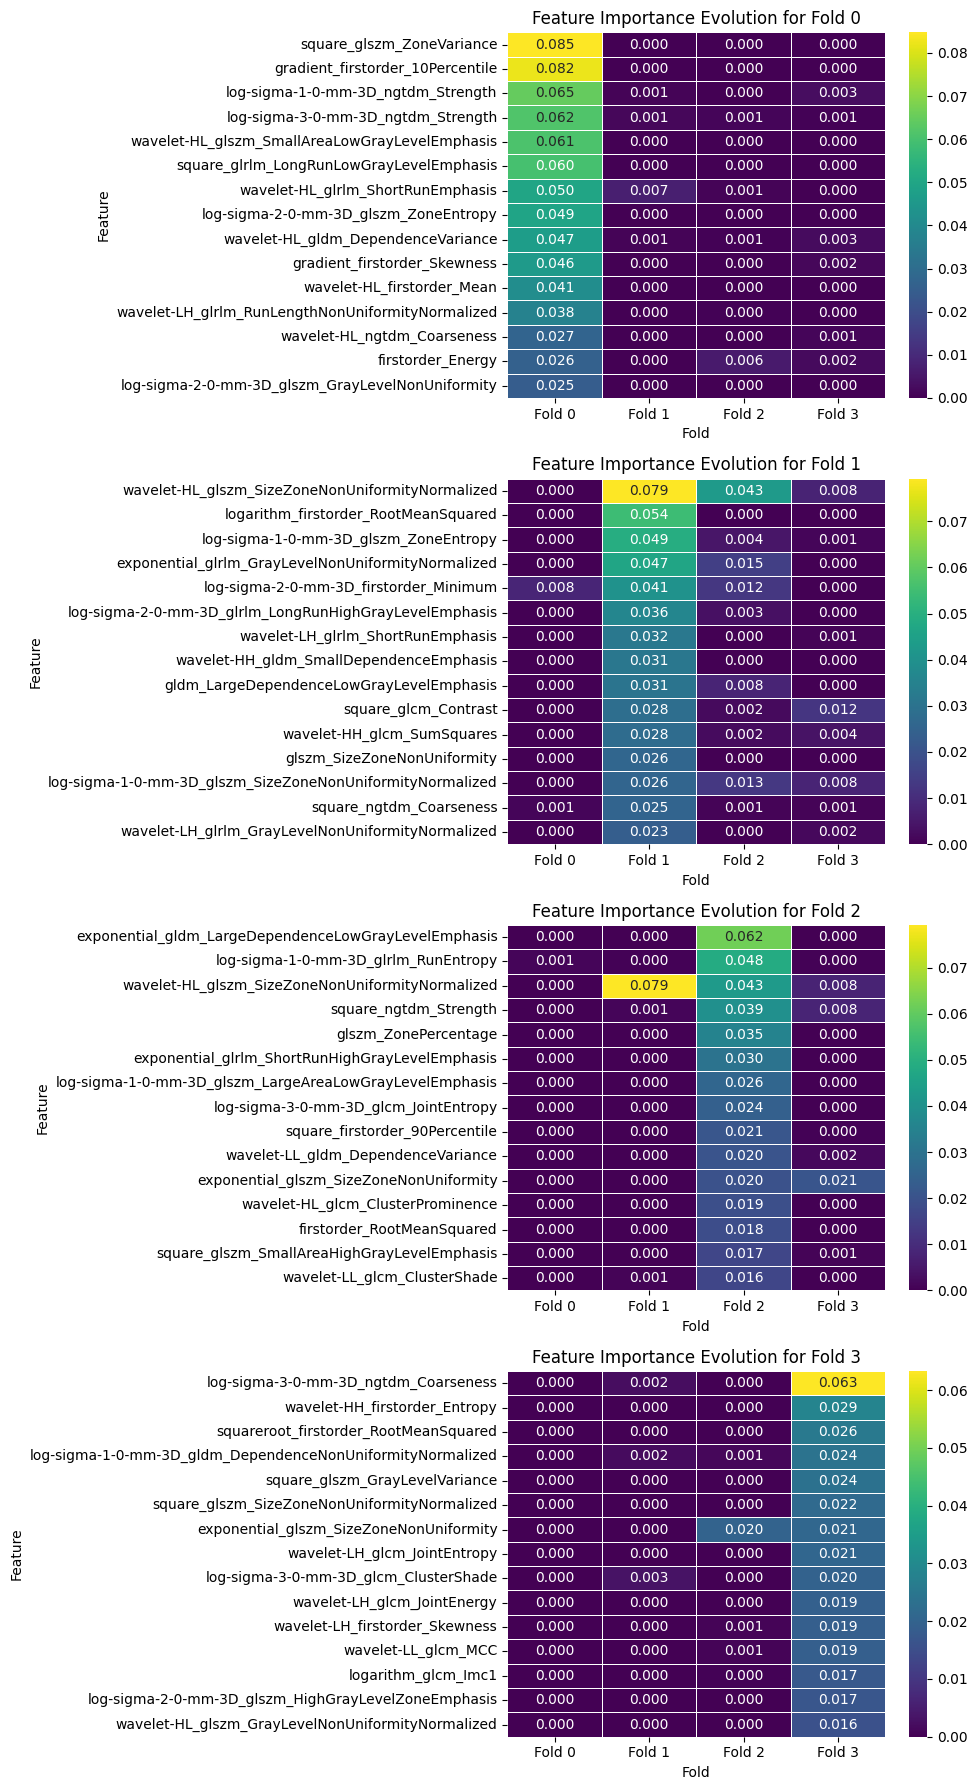

In [ ]:

# Prepare data storage
feature_importance_data = []

# Iterate over the folds to load top feature data
for fold in range(4):  # Assuming there are 4 folds
    fold_file = os.path.join(OUTPUT_DIR, split_method, f"fold_{fold}", "top_features.csv")
    
    # Check if the file exists
    if os.path.exists(fold_file):
        fold_features = pd.read_csv(fold_file)
        
        # Extract the top 15 features by importance
        top_features_fold = fold_features.nlargest(15, 'importance')  # Top 15 features by importance
        feature_importance_data.append(top_features_fold)

# Load the aggregated features data to track importance over folds
aggregated_features_file = os.path.join(OUTPUT_DIR, split_method, 'top_features', 'aggregated_features_with_folds.csv')
aggregated_features = pd.read_csv(aggregated_features_file)

# Prepare the plotting data: we'll track importance evolution across the 4 folds
# We'll use the top features from fold 0 as a reference
top_features = feature_importance_data[0]['feature']  # Assuming same top features for all folds

# Prepare subplots for each fold (4 rows, 1 column)
fig, axs = plt.subplots(4, 1, figsize=(10, 18))  # 4 subplots (1 per row)

# Iterate over each fold and plot the feature importance heatmap
for i, fold_data in enumerate(feature_importance_data):
    # Get the top 15 features for this fold
    top_features_fold = fold_data.nlargest(15, 'importance')['feature']
    
    # Initialize a list to store the importance values for this fold
    fold_importance = []

    # Get the corresponding importance values from aggregated features file
    for feature in top_features_fold:
        importance_values = aggregated_features[aggregated_features['feature'] == feature][
            [f'Fold_{fold}_importance' for fold in range(4)]].values.flatten()
        fold_importance.append(importance_values)

    # Convert the fold importance data into a DataFrame for heatmap plotting
    fold_importance_df = pd.DataFrame(fold_importance, columns=[f'Fold {j}' for j in range(4)], index=top_features_fold)

    # Plot the heatmap for this fold
    ax = axs[i]
    sns.heatmap(fold_importance_df, annot=True, cmap='viridis', ax=ax, cbar=True, fmt=".3f", linewidths=0.5)

    ax.set_title(f'Feature Importance Evolution for Fold {i}')
    ax.set_xlabel('Fold')
    ax.set_ylabel('Feature')

# Adjust layout
plt.tight_layout()
plt.show()
